In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# =========================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam


2026-02-19 08:17:16.536148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771489036.763921      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771489036.827935      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771489037.358726      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771489037.358773      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771489037.358776      55 computation_placer.cc:177] computation placer alr

In [2]:
# =========================================================
# CELL 2: DEFINE CONFIGURATION PARAMETERS
# =========================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8

DATASET_PATH = "/kaggle/input/datasets/vencerlanz09/agricultural-pests-image-dataset"


In [3]:
# =========================================================
# CELL 3: DATASET LOADING
# =========================================================

images = []
labels = []

class_names = sorted(os.listdir(DATASET_PATH))

for class_idx, class_name in enumerate(class_names):

    class_folder = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):

            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                images.append(img)
                labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

print("Dataset Loaded Successfully")
print("Images Shape:", images.shape)


Dataset Loaded Successfully
Images Shape: (5494, 224, 224, 3)


In [4]:
# =========================================================
# CELL 4: APPLY CLAHE IMAGE ENHANCEMENT
# =========================================================

def apply_clahe(image):

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

processed_images = np.array([apply_clahe(img) for img in images])
processed_images = processed_images / 255.0


In [5]:
# =========================================================
# CELL 5: TRAIN-VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    processed_images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)


In [6]:
# =========================================================
# CELL 6: PATCH EXTRACTION & ENCODING
# =========================================================

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
        return self.projection(patches) + self.position_embedding(positions)


In [7]:
# =========================================================
# CELL 7: BUILD HYBRID ResNet50 + ViT (Simple Fusion)
# =========================================================

inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# ---------------- CNN BRANCH (ResNet50) ----------------
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

cnn_features = base_model(inputs)
cnn_features = GlobalAveragePooling2D()(cnn_features)

# ---------------- TRANSFORMER BRANCH ----------------
patches = Patches(PATCH_SIZE)(inputs)
encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

for _ in range(TRANSFORMER_LAYERS):

    x1 = layers.LayerNormalization()(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=PROJECTION_DIM
    )(x1, x1)

    x2 = layers.Add()([attention_output, encoded_patches])

    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(PROJECTION_DIM * 2, activation="gelu")(x3)
    x3 = layers.Dense(PROJECTION_DIM)(x3)

    encoded_patches = layers.Add()([x3, x2])

vit_features = layers.LayerNormalization()(encoded_patches)
vit_features = layers.GlobalAveragePooling1D()(vit_features)

# ---------------- SIMPLE FUSION ----------------
fused = Concatenate()([cnn_features, vit_features])

fused = Dropout(0.3)(fused)
outputs = Dense(len(class_names), activation="softmax")(fused)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1771489209.606614      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771489209.612306      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,340,556 (92.85 MB)

 Trainable params: 15,203,020 (57.99 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [8]:
# =========================================================
# CELL 8: TRAIN HYBRID MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/15


I0000 00:00:1771489254.717503     131 service.cc:152] XLA service 0x7a86ac006990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771489254.717564     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771489254.717574     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771489260.381353     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771489277.311034     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 396ms/step - accuracy: 0.2051 - loss: 2.3367 - val_accuracy: 0.2120 - val_loss: 2.3024
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - accuracy: 0.3799 - loss: 1.8595 - val_accuracy: 0.3076 - val_loss: 2.0982
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.4296 - loss: 1.6962 - val_accuracy: 0.3849 - val_loss: 1.9383
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 197ms/step - accuracy: 0.4610 - loss: 1.6154 - val_accuracy: 0.3394 - val_loss: 2.1240
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.5042 - loss: 1.4606 - val_accuracy: 0.3603 - val_loss: 2.1597
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.5448 - loss: 1.3653 - val_accuracy: 0.3476 - val_loss: 2.1385
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.5709 - loss: 1.2867 - val_accuracy: 0.3576 - val_loss: 2.1813
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 204ms/step - accuracy: 0.6063 - loss: 1.1725 - va

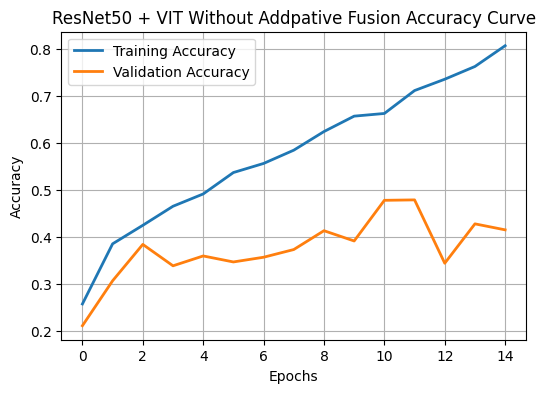

In [12]:
# =========================================================
# CELL 9: ACCURACY CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')

plt.title("ResNet50 + VIT Without Addpative Fusion Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


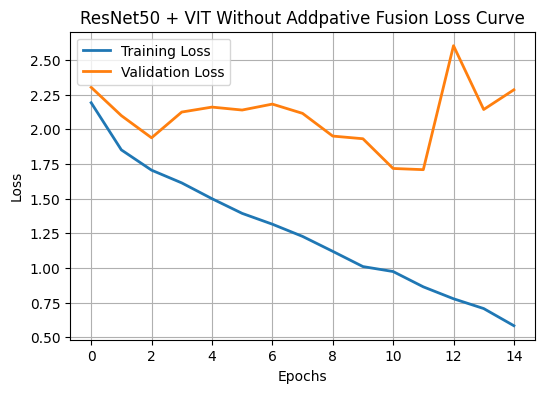

In [15]:
# =========================================================
# CELL 10: LOSS CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')

plt.title("ResNet50 + VIT Without Addpative Fusion Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 279ms/step


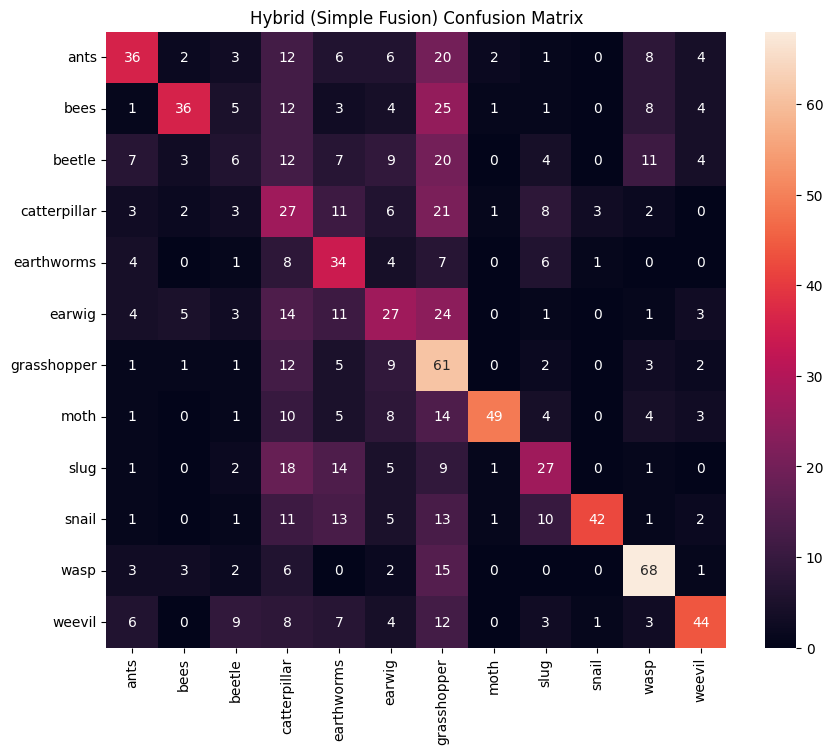

In [13]:
# =========================================================
# CELL 11: CONFUSION MATRIX
# =========================================================

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Hybrid (Simple Fusion) Confusion Matrix")
plt.show()


In [14]:
# =========================================================
# CELL 12: CLASSIFICATION REPORT
# =========================================================

print(classification_report(y_val, y_pred_classes, target_names=class_names))


              precision    recall  f1-score   support

        ants       0.53      0.36      0.43       100
        bees       0.69      0.36      0.47       100
      beetle       0.16      0.07      0.10        83
catterpillar       0.18      0.31      0.23        87
  earthworms       0.29      0.52      0.38        65
      earwig       0.30      0.29      0.30        93
 grasshopper       0.25      0.63      0.36        97
        moth       0.89      0.49      0.64        99
        slug       0.40      0.35      0.37        78
       snail       0.89      0.42      0.57       100
        wasp       0.62      0.68      0.65       100
      weevil       0.66      0.45      0.54        97

    accuracy                           0.42      1099
   macro avg       0.49      0.41      0.42      1099
weighted avg       0.51      0.42      0.43      1099

